# 02. Генерация синтетических доходностей: TimeGAN vs CTGAN

Обучаем два разных GAN на одном и том же реальном train (2010–2019), генерируем по `len(train)=2515` синтетических точек и сравниваем «стилизованные факты»:

| Что хотим увидеть в финансовом ряду | Real | Идеальный synth |
|---|---|---|
| Доходности почти не автокоррелированы (ACF≈0) | да | да |
| **Кластеры волатильности**: ACF |r| > 0 на многих лагах | да | **да** |
| Тяжёлые хвосты (excess kurtosis > 0) | да | да |
| Левая асимметрия (skew < 0) | да | да |

**TimeGAN** (Yoon et al., 2019) — GAN, специально спроектированный под временные ряды (5 модулей: Embedder/Recovery/Generator/Supervisor/Discriminator + supervised loss на следующий шаг embedded-пространства).  
**CTGAN** (Xu et al., 2019) — GAN для **табличных** данных. Мы намеренно режем ряд на окна T=24 и подаём как таблицу из 24 столбцов — это «неправильное» использование, нужное чтобы продемонстрировать, что архитектура GAN критически важна.

Готовый артефакт: `artifacts/synth_timegan.csv`, `artifacts/synth_ctgan.csv`, `artifacts/timegan_history.json`, `artifacts/timegan_model.pt`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as dm

ART = ROOT / "artifacts"
prices, returns = dm.load_or_download()
train, test = dm.train_test_split(returns)

real_pct  = train.values * 100
synth_tg  = pd.read_csv(ART / "synth_timegan.csv")["synth_pct"].values
synth_ct  = pd.read_csv(ART / "synth_ctgan.csv")["synth_pct"].values
print(f"real:    {len(real_pct)}  synth_TimeGAN: {len(synth_tg)}  synth_CTGAN: {len(synth_ct)}")

real:    2515  synth_TimeGAN: 2515  synth_CTGAN: 2515


In [2]:
sf_table = pd.read_csv(ART / "stylized_facts.csv").set_index("name")
sf_table.round(4)

,n,mean,std,skew,kurtosis_excess,min,max,acf1_returns,acf5_returns,acf1_abs_returns,acf5_abs_returns,acf10_abs_returns,acf1_sq_returns,acf5_sq_returns,ljungbox_r_p,ljungbox_sq_p
name,,,,,,,,,,,,,,,,
real_train,2515,0.0417,0.9317,-0.4970,4.5970,-6.8958,4.8403,-0.0462,-0.0782,0.2138,0.2013,0.2003,0.2438,0.1870,0.0010,0.0000
synth_timegan,2515,-0.0238,0.9312,-0.0516,-1.5665,-1.7843,1.4272,-0.7411,-0.0360,0.2101,-0.0243,0.0114,0.2040,-0.0166,0.0000,0.0000
synth_ctgan,2515,-0.0001,1.3667,-0.5355,3.5827,-8.6638,7.1449,-0.0502,-0.0026,-0.0074,0.0016,-0.0367,-0.0065,-0.0132,0.0119,0.8076


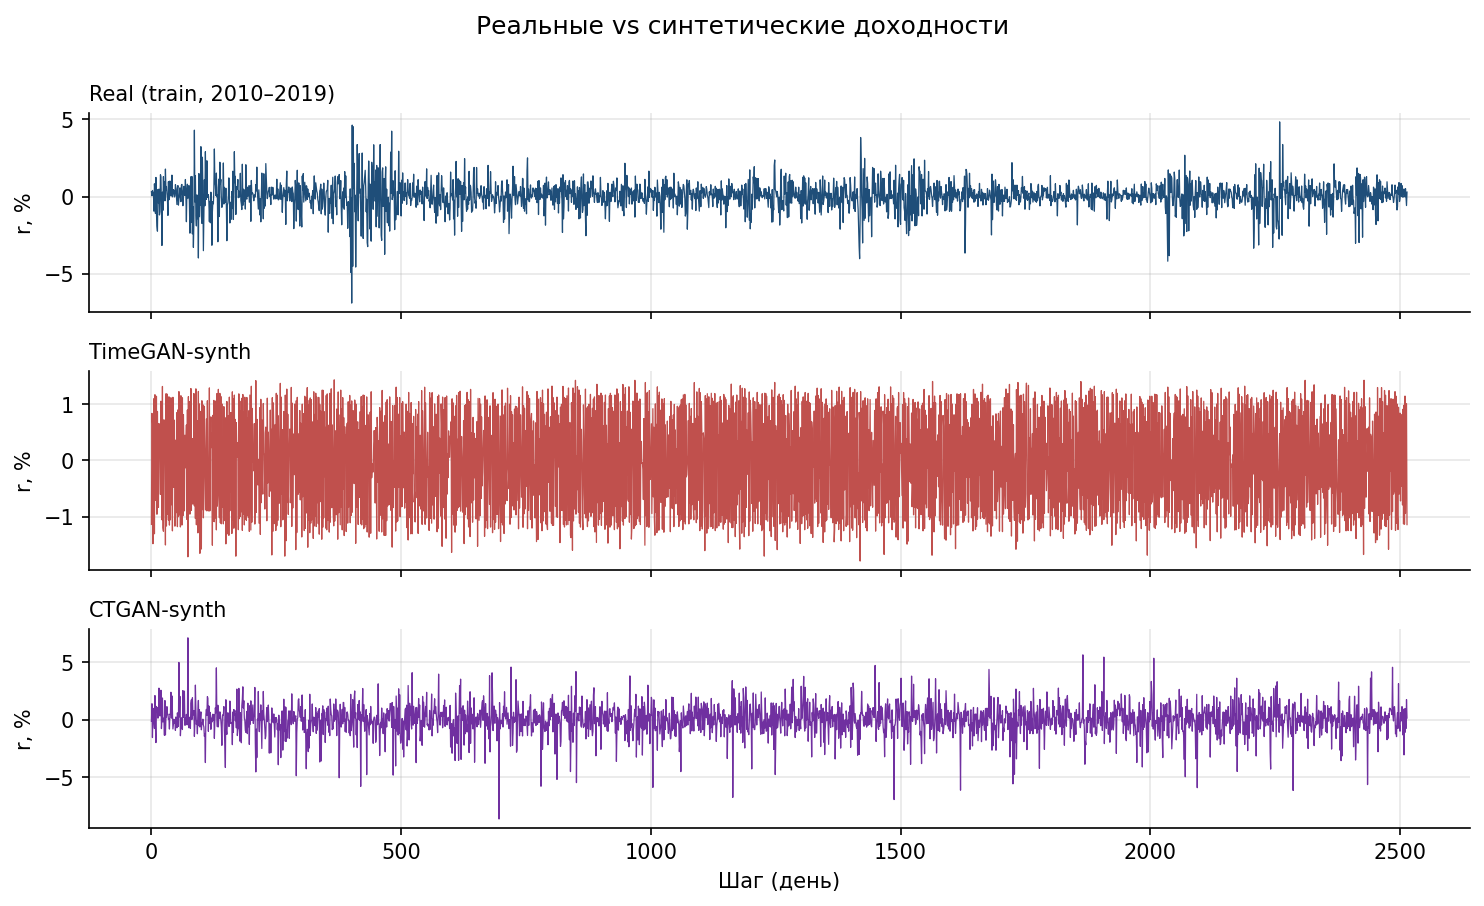

In [3]:
from IPython.display import Image
Image(filename="artifacts/figures/02_real_vs_synth_series.png")

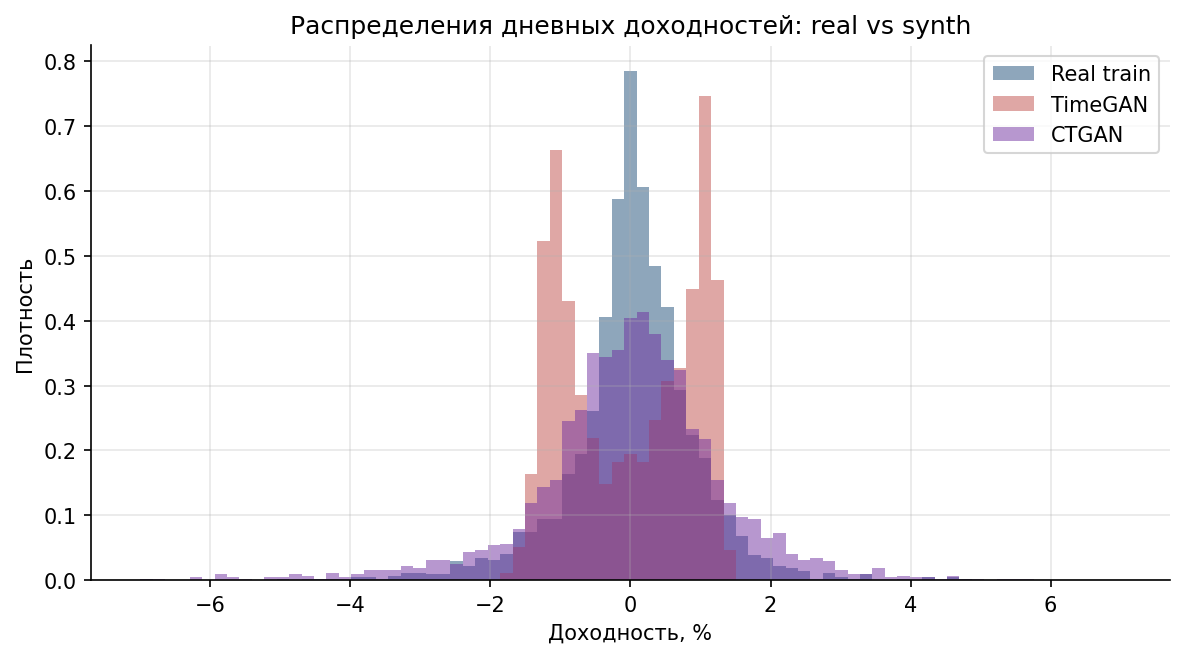

In [4]:
Image(filename="artifacts/figures/03_distributions.png")

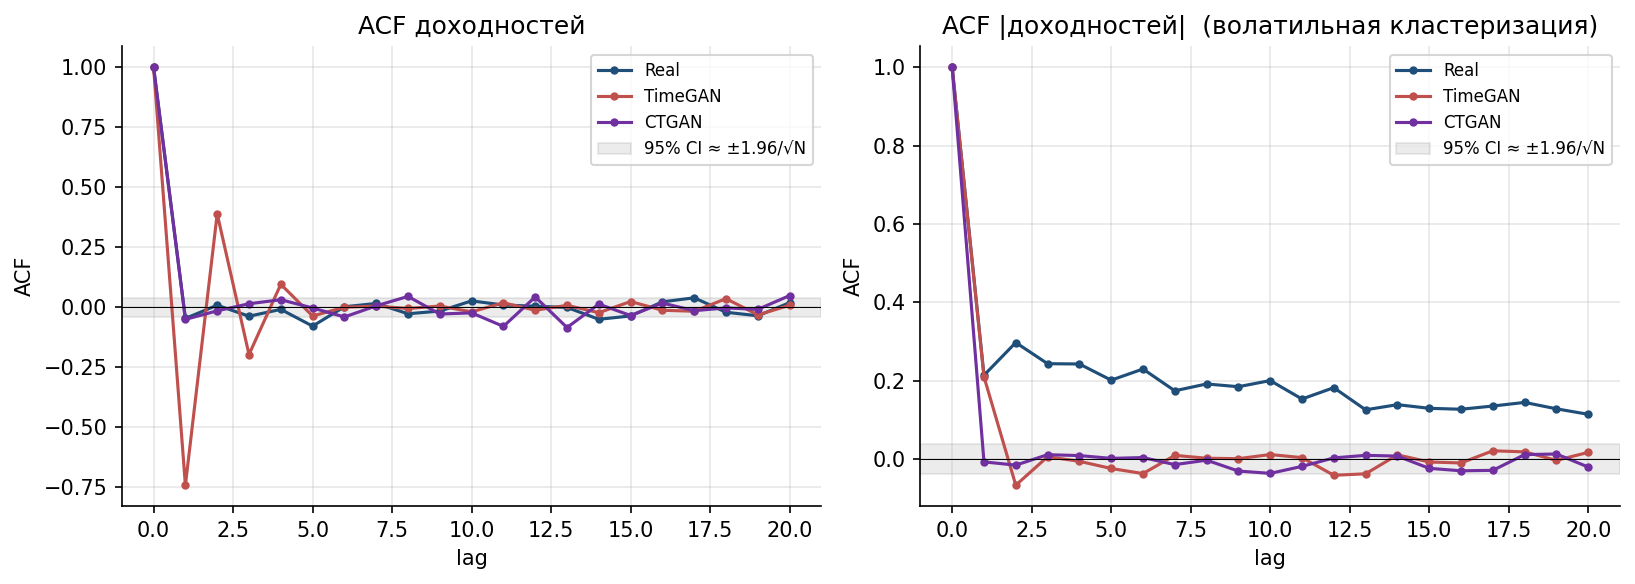

In [5]:
Image(filename="artifacts/figures/04_acf_compare.png")

**Что показали стилизованные факты:**

* **TimeGAN** — кластеры волатильности на коротком лаге сохранены (ACF |r| на лаге 1 ≈ 0.21 ≈ как у real), но на лагах 5–10 распались (≈ 0). Хвосты обрезаны: размах синтетики ±1.5%, тогда как у real ±7%. Excess kurtosis отрицательный — распределение «слишком плоское».
* **CTGAN** — наоборот, размах и форма распределения близки к real (kurtosis ≈ 3.6), но **временная структура полностью разрушена**: ACF |r| ≈ 0 на всех лагах. Это и должно было случиться: CTGAN не моделирует порядок, он моделирует совместное распределение 24 столбцов «как таблицу».

**Вывод по генерации:** TimeGAN частично сохраняет временные свойства, но штрафует хвосты. CTGAN сохраняет распределение, но убивает структуру. Ни один не идеален — это главное содержательное наблюдение для следующей секции.